In [15]:
# 1. Imports

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import time
import os

In [17]:
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")

X_val = np.load("X_val.npy")
y_val = np.load("y_val.npy")

X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

In [19]:
# 2. Device setup

print("PyTorch version:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.6.0
MPS available: True
Using device: mps


In [21]:
# 3. Load preprocessed RoNIN arrays

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (198036, 200, 9)
y_train: (198036, 2)
X_val: (82656, 200, 9)
y_val: (82656, 2)
X_test: (76894, 200, 9)
y_test: (76894, 2)


In [23]:
# 4. Dataset Class

class RoNINDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [25]:
# 5. DataLoaders

batch_size = 64

train_dataset = RoNINDataset(X_train, y_train)
val_dataset = RoNINDataset(X_val, y_val)
test_dataset = RoNINDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [27]:
# 6. TCN Block

class TCNBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        dilation,
        dropout
    ):
        super().__init__()

        padding = (kernel_size - 1) * dilation

        self.conv = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation
        )

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        if in_channels != out_channels:
            self.residual = nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=1
            )
        else:
            self.residual = nn.Identity()

    def forward(self, x):

        out = self.conv(x)

        # keep same sequence length
        out = out[:, :, :x.size(2)]

        out = self.relu(out)
        out = self.dropout(out)

        residual = self.residual(x)

        return out + residual

In [29]:
# 7. Full TCN Model

class TCNHeadingModel(nn.Module):

    def __init__(
        self,
        input_channels=9,
        channels=64,
        kernel_size=3,
        dropout=0.2
    ):
        super().__init__()

        self.tcn = nn.Sequential(

            TCNBlock(
                input_channels,
                channels,
                kernel_size,
                dilation=1,
                dropout=dropout
            ),

            TCNBlock(
                channels,
                channels,
                kernel_size,
                dilation=2,
                dropout=dropout
            ),

            TCNBlock(
                channels,
                channels,
                kernel_size,
                dilation=4,
                dropout=dropout
            ),

            TCNBlock(
                channels,
                channels,
                kernel_size,
                dilation=8,
                dropout=dropout
            )
        )

        self.fc = nn.Linear(channels, 2)

    def forward(self, x):

        # batch, 200, 9 -> batch, 9, 200
        x = x.permute(0, 2, 1)

        out = self.tcn(x)

        # final timestep
        out = out[:, :, -1]

        out = self.fc(out)

        return out

In [31]:
# 8. Initialize Model

model = TCNHeadingModel(
    input_channels=9,
    channels=64,
    kernel_size=3,
    dropout=0.2
).to(device)

print(model)

total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total trainable parameters:", total_params)

TCNHeadingModel(
  (tcn): Sequential(
    (0): TCNBlock(
      (conv): Conv1d(9, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (relu): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
      (residual): Conv1d(9, 64, kernel_size=(1,), stride=(1,))
    )
    (1): TCNBlock(
      (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (relu): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
      (residual): Identity()
    )
    (2): TCNBlock(
      (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(4,))
      (relu): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
      (residual): Identity()
    )
    (3): TCNBlock(
      (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(8,))
      (relu): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
      (residual): Identity()
    )
  )
  (fc): Linear(in_features=64, out_features=2, bias=True)
)
Total trainable parameters: 39618


In [33]:
# 9. Loss and Optimizer

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [35]:
# 10. Train and Validation Functions

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(loader.dataset)

    return epoch_loss


def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = criterion(predictions, y_batch)

            running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(loader.dataset)

    return epoch_loss

In [37]:
# 11. Training Loop with Early Stopping

num_epochs = 50
patience = 5

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

start_time = time.time()

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            "best_tcn_model.pth"
        )

    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

end_time = time.time()

training_time = end_time - start_time

print("Training time (seconds):", training_time)
print("Training time (minutes):", training_time / 60)

Epoch 01 | Train Loss: 0.470667 | Val Loss: 0.457434
Epoch 02 | Train Loss: 0.446191 | Val Loss: 0.445605
Epoch 03 | Train Loss: 0.432637 | Val Loss: 0.433262
Epoch 04 | Train Loss: 0.423342 | Val Loss: 0.432111
Epoch 05 | Train Loss: 0.416983 | Val Loss: 0.427309
Epoch 06 | Train Loss: 0.413058 | Val Loss: 0.422867
Epoch 07 | Train Loss: 0.408223 | Val Loss: 0.422205
Epoch 08 | Train Loss: 0.405479 | Val Loss: 0.424721
Epoch 09 | Train Loss: 0.401986 | Val Loss: 0.425416
Epoch 10 | Train Loss: 0.400387 | Val Loss: 0.421344
Epoch 11 | Train Loss: 0.398727 | Val Loss: 0.418253
Epoch 12 | Train Loss: 0.396480 | Val Loss: 0.423171
Epoch 13 | Train Loss: 0.395056 | Val Loss: 0.424061
Epoch 14 | Train Loss: 0.393486 | Val Loss: 0.419489
Epoch 15 | Train Loss: 0.392722 | Val Loss: 0.418014
Epoch 16 | Train Loss: 0.391355 | Val Loss: 0.415429
Epoch 17 | Train Loss: 0.390435 | Val Loss: 0.413342
Epoch 18 | Train Loss: 0.389670 | Val Loss: 0.416509
Epoch 19 | Train Loss: 0.388639 | Val Loss: 0.

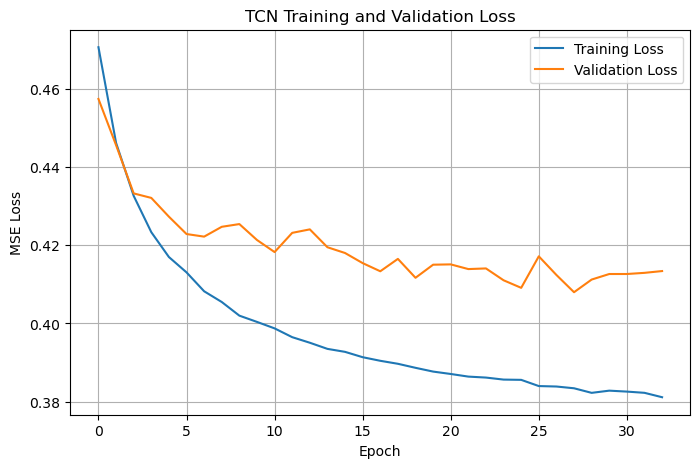

In [39]:
# 12. Plot Loss Curve

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title("TCN Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [41]:
# 13. Load Best Model

model.load_state_dict(
    torch.load(
        "best_tcn_model.pth",
        map_location=device
    )
)

model.eval()

TCNHeadingModel(
  (tcn): Sequential(
    (0): TCNBlock(
      (conv): Conv1d(9, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (relu): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
      (residual): Conv1d(9, 64, kernel_size=(1,), stride=(1,))
    )
    (1): TCNBlock(
      (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (relu): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
      (residual): Identity()
    )
    (2): TCNBlock(
      (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(4,))
      (relu): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
      (residual): Identity()
    )
    (3): TCNBlock(
      (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(8,))
      (relu): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
      (residual): Identity()
    )
  )
  (fc): Linear(in_features=64, out_features=2, bias=True)
)

In [43]:
# 14. Circular MAE / RMSE

def sincos_to_degrees(y):

    sin_vals = y[:, 0]
    cos_vals = y[:, 1]

    angles = np.degrees(
        np.arctan2(sin_vals, cos_vals)
    )

    angles = (angles + 360) % 360

    return angles


def circular_error(pred, true):

    diff = np.abs(pred - true)

    return np.minimum(diff, 360 - diff)


all_predictions = []
all_targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        predictions = model(X_batch)

        all_predictions.append(
            predictions.cpu().numpy()
        )

        all_targets.append(
            y_batch.numpy()
        )

all_predictions = np.vstack(all_predictions)
all_targets = np.vstack(all_targets)

pred_deg = sincos_to_degrees(all_predictions)
true_deg = sincos_to_degrees(all_targets)

errors = circular_error(pred_deg, true_deg)

test_mae = np.mean(errors)
test_rmse = np.sqrt(np.mean(errors ** 2))

print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)

Test MAE: 69.2654
Test RMSE: 85.996635


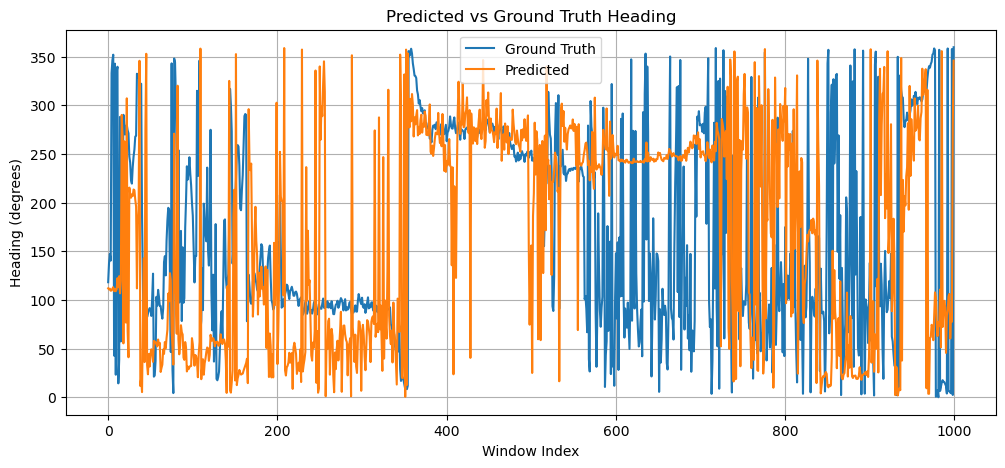

In [45]:
# 15. Predicted vs Ground Truth Plot

num_points = 1000

plt.figure(figsize=(12, 5))

plt.plot(
    true_deg[:num_points],
    label="Ground Truth"
)

plt.plot(
    pred_deg[:num_points],
    label="Predicted"
)

plt.xlabel("Window Index")
plt.ylabel("Heading (degrees)")

plt.title("Predicted vs Ground Truth Heading")

plt.legend()
plt.grid(True)

plt.show()

In [49]:
# Scenario-wise MAE breakdown
# Straight walking: small heading change between consecutive windows
# Sharp turns: large heading change between consecutive windows

heading_change = np.abs(np.diff(true_deg, prepend=true_deg[0]))
heading_change = np.minimum(heading_change, 360 - heading_change)

straight_mask = heading_change <= 10
sharp_turn_mask = heading_change >= 45

# In this notebook we do not have trajectory IDs, so short/long are approximated
# by splitting the unseen test windows into two equal-sized parts.
midpoint = len(errors) // 2
short_mask = np.zeros_like(errors, dtype=bool)
long_mask = np.zeros_like(errors, dtype=bool)
short_mask[:midpoint] = True
long_mask[midpoint:] = True

def safe_mae(mask):
    if np.sum(mask) == 0:
        return np.nan
    return np.mean(errors[mask])

scenario_results = {
    "Straight walking": safe_mae(straight_mask),
    "Sharp turns": safe_mae(sharp_turn_mask),
    "Short trajectories": safe_mae(short_mask),
    "Long trajectories": safe_mae(long_mask)
}

print("Scenario-wise MAE")
for scenario, value in scenario_results.items():
    print(f"{scenario}: {value:.4f} degrees")

with open("tcn_results_summary.txt", "w") as f:
    f.write("TCN Results Summary\n")
    f.write("===================\n")
    f.write(f"Test MAE: {test_mae:.4f} degrees\n")
    f.write(f"Test RMSE: {test_rmse:.4f} degrees\n")
    f.write(f"Training time: {training_time/60:.2f} minutes\n")
    f.write(f"Total trainable parameters: {total_params}\n")
    f.write("\nScenario-wise MAE\n")
    for scenario, value in scenario_results.items():
        f.write(f"{scenario}: {value:.4f} degrees\n")

print("Saved tcn_results_summary.txt")


Scenario-wise MAE
Straight walking: 63.3921 degrees
Sharp turns: 87.8784 degrees
Short trajectories: 74.3783 degrees
Long trajectories: 64.1524 degrees
Saved tcn_results_summary.txt
